In [19]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

In [4]:
transform = transforms.Compose([
    transforms.ToTensor()
])

In [5]:
train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

100%|██████████| 9.91M/9.91M [00:16<00:00, 584kB/s] 
100%|██████████| 28.9k/28.9k [00:00<00:00, 106kB/s]
100%|██████████| 1.65M/1.65M [00:05<00:00, 301kB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.88MB/s]


In [6]:
print("Training samples:", len(train_dataset))
print("Testing samples:", len(test_dataset))

Training samples: 60000
Testing samples: 10000


In [7]:
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

Image shape: torch.Size([1, 28, 28])
Label: 5


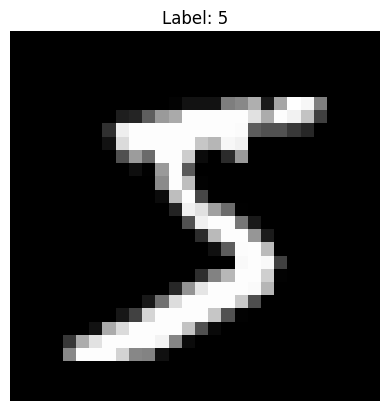

In [8]:
image, label = train_dataset[0]

print("Image shape:", image.shape)
print("Label:", label)

plt.imshow(image.squeeze(), cmap="gray")
plt.title(f"Label: {label}")
plt.axis("off")
plt.show()

In [10]:
class MyANN(nn.Module):

    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(

            # 28 x 28 = 784 input features
            nn.Flatten(),

            # Input layer → Hidden layer
            nn.Linear(784, 128),

            # Activation function
            nn.ReLU(),

            # Hidden layer
            nn.Linear(128, 64),

            # Activation function
            nn.ReLU(),

            # Output layer
            nn.Linear(64, 10)
        )

    def forward(self, x):
        return self.model(x)


# Create model
model = MyANN()

# Move model to CPU/GPU


print(model)

MyANN(
  (model): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Linear(in_features=64, out_features=10, bias=True)
  )
)


In [11]:
criterion = nn.CrossEntropyLoss()

In [12]:
optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

In [13]:
epochs = 10

train_losses = []
train_accuracies = []

for epoch in range(epochs):

    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        # ----------------------------------------
        # Forward Pass
        # ----------------------------------------

        outputs = model(images)

        # Calculate loss
        loss = criterion(outputs, labels)

        # ----------------------------------------
        # Backward Pass
        # ----------------------------------------

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        # ----------------------------------------
        # Calculate accuracy
        # ----------------------------------------

        total_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()


    # Epoch results

    epoch_loss = total_loss / len(train_loader)

    epoch_accuracy = 100 * correct / total

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_accuracy)

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Loss: {epoch_loss:.4f} "
        f"Accuracy: {epoch_accuracy:.2f}%"
    )


Epoch [1/10] Loss: 0.3430 Accuracy: 90.30%
Epoch [2/10] Loss: 0.1424 Accuracy: 95.78%
Epoch [3/10] Loss: 0.0950 Accuracy: 97.08%
Epoch [4/10] Loss: 0.0714 Accuracy: 97.81%
Epoch [5/10] Loss: 0.0563 Accuracy: 98.26%
Epoch [6/10] Loss: 0.0435 Accuracy: 98.61%
Epoch [7/10] Loss: 0.0364 Accuracy: 98.81%
Epoch [8/10] Loss: 0.0293 Accuracy: 99.07%
Epoch [9/10] Loss: 0.0225 Accuracy: 99.31%
Epoch [10/10] Loss: 0.0220 Accuracy: 99.25%


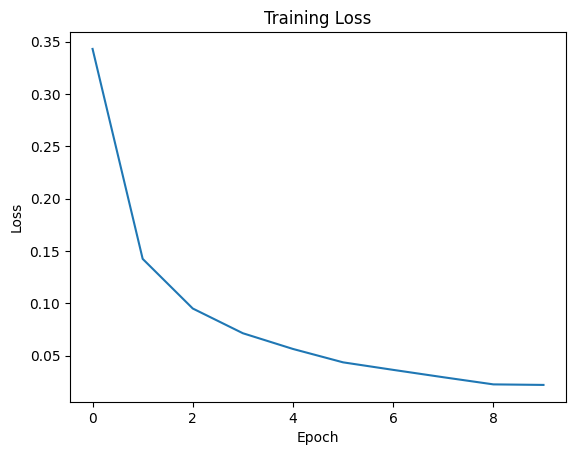

In [14]:
plt.plot(train_losses)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Training Loss")

plt.show()

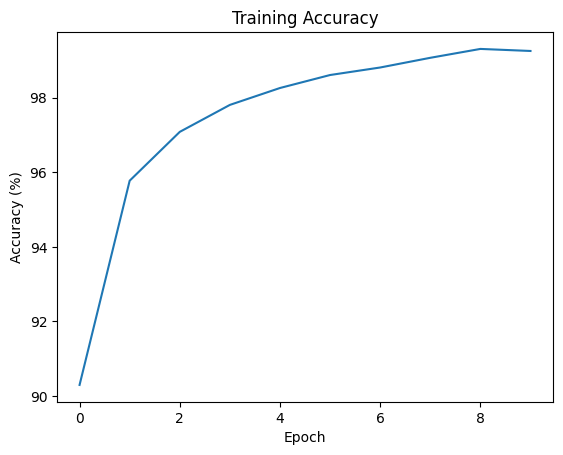

In [15]:
plt.plot(train_accuracies)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")

plt.title("Training Accuracy")

plt.show()

In [17]:
model.eval()

correct = 0
total = 0

all_labels = []
all_predictions = []

with torch.no_grad():

    for images, labels in test_loader:

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

        # Store labels and predictions
        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())


test_accuracy = 100 * correct / total

print()
print("Test Accuracy:", test_accuracy)


Test Accuracy: 97.83


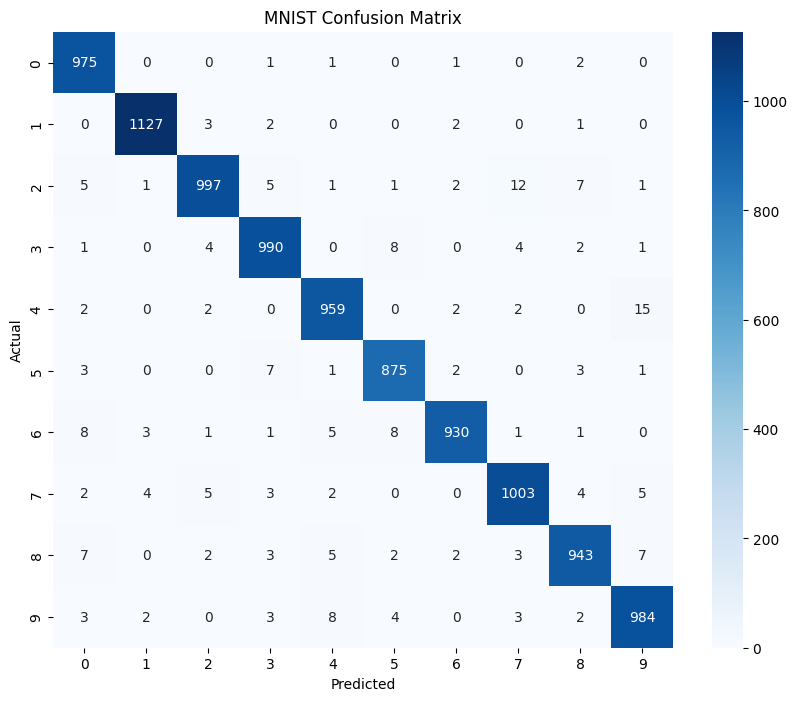

In [20]:
cm = confusion_matrix(
    all_labels,
    all_predictions
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("MNIST Confusion Matrix")

plt.show()
